# Q8.
```{admonition}
:class: note
We will now perform cross-validation on a simulated data set.

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold

## (a)
```{admonition}
:class: note
A data set is simulated below. In this data set, what is $n$ and $p$? Write out the model used to generate the data in equation form.

In [4]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x-2*x**2+rng.normal(size=100)

For this set $n = 100$, the number of data points generated, and $p = 2$, the non-error terms in the equation $Y = X-2X^{2}+\varepsilon$.

## (b)
```{admonition}
:class: note
Create a scatterplot of $X$ against $Y$.

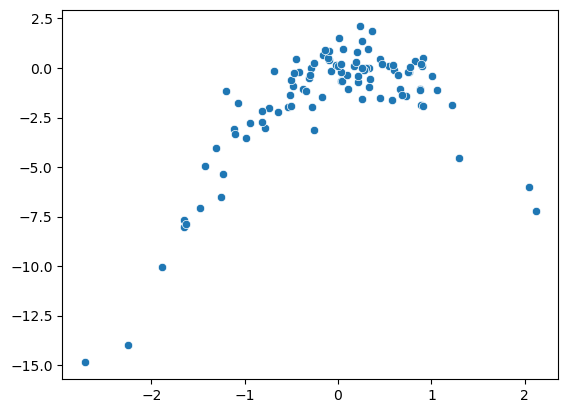

In [5]:
sns.scatterplot(x=x,y=y);

## (c)
```{admonition}
:class: note
Set a random seed and then compute the LOOCV that result from fitting the following four models using least squares.

In [6]:
df = pd.DataFrame({'X':x,'Y':y})

In [ ]:
lr = LinearRegression()
cv_errors = np.empty(4)
cv = KFold(n_splits = x.shape[0],random_state=1728,shuffle=True)
for i in range(4):
    poly = PolynomialFeatures(i+1)
    X = df[['X']]
    Y = df[['Y']]
    cv_ = cross_validate(lr,scoring='neg_mean_squared_error',X=poly.fit_transform(X), y=Y,cv=cv)
    cv_errors[i] = -cv_['test_score'].mean()

i. $Y = \beta_{0}+\beta_{1}X+\varepsilon$

In [31]:
print('The LOOCV is:', cv_errors[0])

The LOOCV is: 6.633029839181983


ii. $Y = \beta_{0}+\beta_{1}X+\beta_{2}X^{2}+\varepsilon$

In [12]:
print('The LOOCV is:', cv_errors[1])

The LOOCV is: 1.122936856341969


iii. $Y = \beta_{0}+\beta_{1}X+\beta_{2}X^{2}+\beta_{3}X^{3}+\varepsilon$

In [13]:
print('The LOOCV is:', cv_errors[2])

The LOOCV is: 1.3017965489358871


iv. $Y = \beta_{0}+\beta_{1}X+\beta_{3}X^{3}+\beta_{4}X^{4}+\varepsilon$

In [14]:
print('The LOOCV is:', cv_errors[3])

The LOOCV is: 1.3323942694179371


## (d)
```{admonition}
:class: note
Repeat (c) using another random seed and report your results. Are you results the same as (c)? Why?

In [15]:
lr = LinearRegression()
cv_errors2 = np.empty(4)
cv = KFold(n_splits = x.shape[0],random_state=577,shuffle=True)
for i in range(4):
    poly = PolynomialFeatures(i+1)
    X = df[['X']]
    Y = df[['Y']]
    cv_ = cross_validate(lr,scoring='neg_mean_squared_error',X=poly.fit_transform(X), y=Y,cv=cv)
    cv_errors2[i] = -cv_['test_score'].mean()
print(cv_errors2)

[6.63302984 1.12293686 1.30179655 1.33239427]


LOOCV is completely deterministic since we need to make $n$ folds and only have $n$ data points. The only difference is the order in which the cross validation is done, but every data point is eventually checked.

## (e)
```{admonition}
:class: note
Which of the models in (c) had the smallest LOOCV error? Is this what you expected?

The lowest LOOCV was for the quadratic model. Since the underlying data is quadratic, this is not unexpected.

## (f)
```{admonition}
:class: note
Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

In [26]:
for i in range(4):
    poly = PolynomialFeatures(i+1)
    X = poly.fit_transform(df[['X']])
    Y = df[['Y']]
    model = sm.OLS(Y,X)
    res = model.fit()
    print(res.summary())
    print('\n'*2)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.04e-09
Time:                        23:43:58   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650      0.247     -5.937      0.0

The linear, quadratic, and quartic terms are statistically significant at $p=0.05$. However, we note that this is testing multiple hypothesis, which inflates the possibility of statistical significance by chance. Using Bonferonni, say, we would check at $p=0.01$ instead and then we no longer reject the null hypothesis of $\beta_{4} = 0$.